# Single and double floating-point precision

mumax⁺ can use either single (32-bit) or double (64-bit) floating-point precision.
By default, single precision is used.

## Choosing a precision

The choice of floating-point precision affects all of mumax⁺, and must therefore be made **before** the line `import mumaxplus` is reached.
Two switches determine which precision will then be loaded, as listed below in descending order of priority.
Both accept the values `SINGLE`/`1`/`32` for single precision and `DOUBLE`/`2`/`64` for double precision.

- **The `--mumaxplus-fp-precision` command-line flag.** Example:
  
  ```shell
  python some_mumax_script.py --mumaxplus-fp-precision DOUBLE
  ```

- **The `MUMAXPLUS_FP_PRECISION` environment variable.**
  If set globally on your system, this will also affect the compilation process, as explained below.
  It can also be set locally inside a single Python script by writing
  ```python
  import os
  os.environ["MUMAXPLUS_FP_PRECISION"] = "DOUBLE"
  ```
  **before** the `import mumaxplus` statement.

The precision ultimately used by mumax⁺ can be accessed as `mumaxplus.FP_PRECISION`, which will be either `"SINGLE"` or `"DOUBLE"`.

### Compilation

Compiling mumax⁺ normally results in two binaries: one for single and one for double precision.
However, if the environment variable `MUMAXPLUS_FP_PRECISION` is set, only one binary will be produced, corresponding to desired precision.
This can be useful to reduce compile time during development, if only one precision is needed.

## Possible errors

- Using `MUMAXPLUS_FP_PRECISION` to compile the source code for only one floating-point precision, and then asking for the opposite precision with `--mumaxplus-fp-precision` when running a script, will result in a `ModuleNotFoundError`.

- Since the choice of precision must be made before the `import mumaxplus` statement, it is not possible to use single precision in one part of a script and double precision in another: these must be run in separate processes. Reloading mumax⁺ with a different floating-point precision during runtime may lead to a vast wealth of errors.

## Example: error floor

The floating-point precision used has a significant impact on the error floor.

Below, we compare the numerical and analytical result of 10 precessions of one spin in an external magnetic field of 0.1 T, with damping. Depending on the time step, this results in a different error. The minimum attainable error is dependent on the floating-point precision used.

Note that the following cells can take several minutes to run.

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


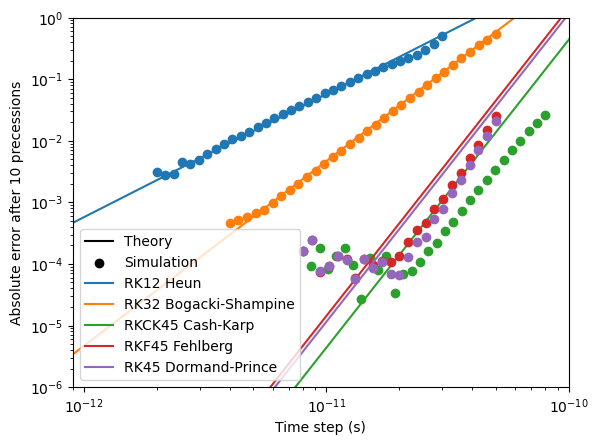

In [1]:
import os
os.environ["MUMAXPLUS_FP_PRECISION"] = "SINGLE"

import matplotlib.pyplot as plt
import numpy as np
from math import acos, atan, pi, exp, tan, sin, cos, sqrt

from mumaxplus import *
from mumaxplus.util import *


def magnetic_moment_precession(time, initial_magnetization, hfield_z, damping):
    """Return the analytical solution of the LLG equation for a single magnetic
    moment and an applied field along the z direction.
    """
    mx, my, mz = initial_magnetization
    theta0 = acos(mz)
    phi0 = atan(my / mx)
    freq = GAMMALL_DEFAULT * hfield_z / (1 + damping ** 2)
    phi = phi0 + freq * time
    theta = pi - 2 * atan(exp(damping * freq * time) * tan(pi / 2 - theta0 / 2))
    return np.array([sin(theta) * cos(phi), sin(theta) * sin(phi), cos(theta)])


def single_system(method, dt):
    """This function simulates a single spin in a magnetic field of 0.1 T without damping.

    Returns the absolute error between the simulation and the exact solution.

    Parameters:
    method -- The used simulation method
    dt     -- The time step
    """
    # --- Setup ---
    world = World(cellsize=(1e-9, 1e-9, 1e-9))
    
    magnetization = (1/np.sqrt(2), 0, 1/np.sqrt(2))
    damping = 0.001
    hfield_z = 0.1  # External field strength
    duration = 2*np.pi/(GAMMALL_DEFAULT * hfield_z) * (1 + damping**2) * 10  # Time of 10 precessions

    magnet = Ferromagnet(world, grid=Grid((1, 1, 1)))
    magnet.enable_demag = False
    magnet.magnetization = magnetization
    magnet.alpha = damping
    magnet.aex = 10e-12
    magnet.msat = 1/MU0
    world.bias_magnetic_field = (0, 0, hfield_z)

    # --- Run the simulation ---
    world.timesolver.set_method(method)
    world.timesolver.adaptive_timestep = False
    world.timesolver.timestep = dt
    
    world.timesolver.run(duration)
    output = magnet.magnetization.average()

    # --- Compare with exact solution ---
    exact = magnetic_moment_precession(duration, magnetization, hfield_z, damping)
    error = np.linalg.norm(exact - output)

    return error


method_names = ["Heun", "BogackiShampine", "CashKarp", "Fehlberg", "DormandPrince"]
exact_names = ["Heun", "Bogacki-Shampine", "Cash-Karp", "Fehlberg", "Dormand-Prince"]
RK_names = ["RK12", "RK32", "RKCK45", "RKF45", "RK45"]
exact_order = [2, 3, 5, 5, 5]
dts_lower = [2e-12, 4e-12, 8e-12, 8e-12, 8e-12] # Lower bounds for the time steps
dts_upper = [3e-11, 5e-11, 8e-11, 5e-11, 5e-11] # Upper bounds for the time steps

N_dens = 30  # Amount of datapoints between two powers of 10
dts = [np.logspace(np.log10(dts_lower[i]), np.log10(dts_upper[i]), int(N_dens*(np.log10(dts_upper[i]) - np.log10(dts_lower[i])))) for i, _ in enumerate(method_names)] # Time step arrays


# --- Plotting ---
plt.xscale('log')
plt.yscale('log')
plt.xlim((0.9e-12, 1e-10))
plt.ylim((1e-6, 1))
plt.xlabel("Time step (s)")
plt.ylabel("Absolute error after 10 precessions")

plt.plot([], [], color="black", label="Theory")  # Labels for theoretical results
plt.scatter([], [], marker="o", color="black", label="Simulation")  # Labels for simulated results

# --- Simulation Loops ---
orders = {}
for i, method in enumerate(method_names):
    error = np.zeros(shape=dts[i].shape)
    for j, dt in enumerate(dts[i]):
        err = single_system(method, dt)
        error[j] = err
    
    # Find the order
    log_dts, log_error = np.log10(dts[i]), np.log10(error)
    order = np.polyfit(log_dts, log_error, 1)[0]
    orders[exact_names[i]] = order

    plt.scatter(dts[i], error, marker="o", zorder=2)

    intercept = np.polyfit(log_dts, log_error - log_dts * exact_order[i], 0)
    plt.plot(np.array([1e-14, 1e-9]), (10**intercept)*np.array([1e-14, 1e-9])**exact_order[i], label=f"{RK_names[i]} {exact_names[i]}")

plt.legend()
plt.show()


In [ ]:
# Restart the kernel so we can load mumax+ again with a different precision.
# This likely gives a popup saying that the kernel was stopped or will restart.
get_ipython().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

findfont: Font family ['DejaVu Sans Display'] not found. Falling back to DejaVu Sans.


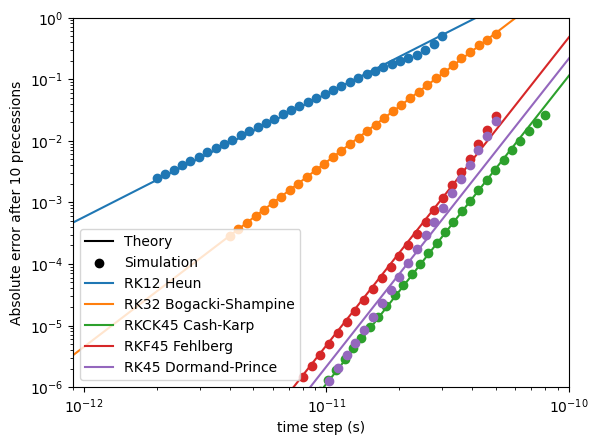

In [1]:
import os
os.environ["MUMAXPLUS_FP_PRECISION"] = "DOUBLE"

import matplotlib.pyplot as plt
import numpy as np
from math import acos, atan, pi, exp, tan, sin, cos, sqrt

from mumaxplus import *
from mumaxplus.util import *


def magnetic_moment_precession(time, initial_magnetization, hfield_z, damping):
    """Return the analytical solution of the LLG equation for a single magnetic
    moment and an applied field along the z direction.
    """
    mx, my, mz = initial_magnetization
    theta0 = acos(mz)
    phi0 = atan(my / mx)
    freq = GAMMALL_DEFAULT * hfield_z / (1 + damping ** 2)
    phi = phi0 + freq * time
    theta = pi - 2 * atan(exp(damping * freq * time) * tan(pi / 2 - theta0 / 2))
    return np.array([sin(theta) * cos(phi), sin(theta) * sin(phi), cos(theta)])


def single_system(method, dt):
    """This function simulates a single spin in a magnetic field of 0.1 T without damping.

    Returns the absolute error between the simulation and the exact solution.

    Parameters:
    method -- The used simulation method
    dt     -- The time step
    """
    # --- Setup ---
    world = World(cellsize=(1e-9, 1e-9, 1e-9))
    
    magnetization = (1/np.sqrt(2), 0, 1/np.sqrt(2))
    damping = 0.001
    hfield_z = 0.1  # External field strength
    duration = 2*np.pi/(GAMMALL_DEFAULT * hfield_z) * (1 + damping**2) * 10  # Time of 10 precessions

    magnet = Ferromagnet(world, grid=Grid((1, 1, 1)))
    magnet.enable_demag = False
    magnet.magnetization = magnetization
    magnet.alpha = damping
    magnet.aex = 10e-12
    magnet.msat = 1/MU0
    world.bias_magnetic_field = (0, 0, hfield_z)

    # --- Run the simulation ---
    world.timesolver.set_method(method)
    world.timesolver.adaptive_timestep = False
    world.timesolver.timestep = dt
    
    world.timesolver.run(duration)
    output = magnet.magnetization.average()

    # --- Compare with exact solution ---
    exact = magnetic_moment_precession(duration, magnetization, hfield_z, damping)
    error = np.linalg.norm(exact - output)

    return error


method_names = ["Heun", "BogackiShampine", "CashKarp", "Fehlberg", "DormandPrince"]
exact_names = ["Heun", "Bogacki-Shampine", "Cash-Karp", "Fehlberg", "Dormand-Prince"]
RK_names = ["RK12", "RK32", "RKCK45", "RKF45", "RK45"]
exact_order = [2, 3, 5, 5, 5]
dts_lower = [2e-12, 4e-12, 8e-12, 8e-12, 8e-12] # Lower bounds for the time steps
dts_upper = [3e-11, 5e-11, 8e-11, 5e-11, 5e-11] # Upper bounds for the time steps

N_dens = 30  # Amount of datapoints between two powers of 10
dts = [np.logspace(np.log10(dts_lower[i]), np.log10(dts_upper[i]), int(N_dens*(np.log10(dts_upper[i]) - np.log10(dts_lower[i])))) for i, _ in enumerate(method_names)] # Time step arrays


# --- Plotting ---
plt.xscale('log')
plt.yscale('log')
plt.xlim((0.9e-12, 1e-10))
plt.ylim((1e-6, 1))
plt.xlabel("time step (s)")
plt.ylabel("Absolute error after 10 precessions")

plt.plot([], [], color="black", label="Theory")  # Labels for theoretical results
plt.scatter([], [], marker="o", color="black", label="Simulation")  # Labels for simulated results

# --- Simulation Loops ---
orders = {}
for i, method in enumerate(method_names):
    error = np.zeros(shape=dts[i].shape)
    for j, dt in enumerate(dts[i]):
        err = single_system(method, dt)
        error[j] = err
    
    # Find the order
    log_dts, log_error = np.log10(dts[i]), np.log10(error)
    order = np.polyfit(log_dts, log_error, 1)[0]
    orders[exact_names[i]] = order

    plt.scatter(dts[i], error, marker="o", zorder=2)

    intercept = np.polyfit(log_dts, log_error - log_dts * exact_order[i], 0)
    plt.plot(np.array([1e-14, 1e-9]), (10**intercept)*np.array([1e-14, 1e-9])**exact_order[i], label=f"{RK_names[i]} {exact_names[i]}")

plt.legend()
plt.show()


With `SINGLE` precision, the error floor after 10 precessions is around $10^{-4}$.
With ``DOUBLE`` precision, however, the error floor reaches much lower.